## Tox24 challenge data preprocessing

- Tox24 challenge provides with:
1. Training set - 1012 samples
2. Leaderboard set - 200 samples
3. Blind set - 300 samples

In this notebook, we preprocess these data, preparing them to be used in the subsequent experiments (encoder selection, etc..)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
## Read data
train_df = pd.read_csv('./data_tox/tox24_challenge_train.csv')
leaderboard_df = pd.read_csv('./data_tox/tox24_challenge_leaderboard.csv')
blind_df = pd.read_csv('./data_tox/tox24_challenge_test.csv')

# Rename columns
leaderboard_df.columns = ['SMILES', 'activity']
blind_df.columns = ['SMILES', 'activity']

# Concatenate training and leaderboard sets
#train_df = pd.concat([train_df, leaderboard_df], ignore_index=True)

In [6]:
# Print dimensions
print(f"Training set: {train_df.shape}")
print(f"Leaderboard set: {leaderboard_df.shape}")
print(f"Blind set: {blind_df.shape}")

Training set: (1012, 2)
Leaderboard set: (200, 2)
Blind set: (300, 2)


Text(0, 0.5, 'Count')

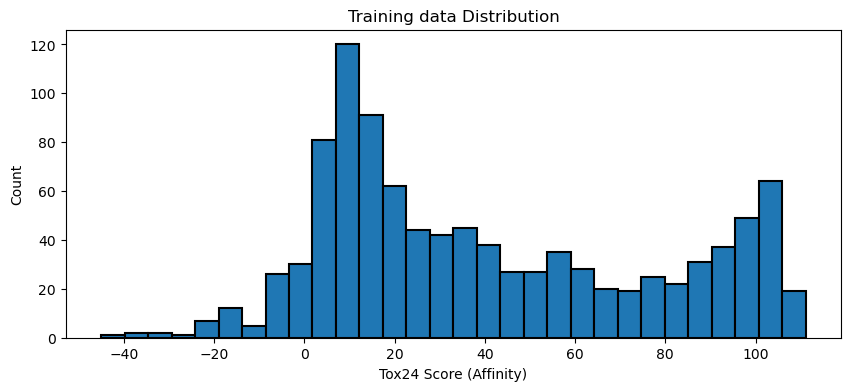

In [7]:
train_y = train_df.activity.to_numpy()
plt.figure(figsize=(10,4))
_ = plt.hist(train_y, bins=30, linewidth=1.5, edgecolor='black')
plt.title("Training data Distribution")
plt.xlabel("Tox24 Score (Affinity)")
plt.ylabel("Count")

### Applying cleaning procedures

- canonicalize SMILES
- remove salts

In [8]:
from rdkit import Chem
import re

def remove_cl_salts(smiles):
    """
    Remove salt fragments such as .cl, .cl.cl, .Cl, and .Cl.Cl from SMILES.
    """
    if pd.isna(smiles) or smiles is None:
        return None
    
    # Remove .cl, .cl.cl, .Cl, .Cl.Cl patterns (case-insensitive)
    cleaned_smiles = re.sub(r'\.cl\.cl\.?', '', smiles, flags=re.IGNORECASE)  # .cl.cl or .cl.cl.
    cleaned_smiles = re.sub(r'\.cl\.?', '', cleaned_smiles, flags=re.IGNORECASE)  # .cl or .cl.
    
    # Additional cleanup for .Cl and .Cl.Cl variants
    cleaned_smiles = re.sub(r'\.Cl\.Cl\.?', '', cleaned_smiles)  # .Cl.Cl or .Cl.Cl.
    cleaned_smiles = re.sub(r'\.Cl\.?', '', cleaned_smiles)  # .Cl or .Cl.
    
    # Remove repeated dots (e.g., .. -> .)
    cleaned_smiles = re.sub(r'\.+', '.', cleaned_smiles)
    
    # Trim leading/trailing dots
    cleaned_smiles = cleaned_smiles.strip('.')
    
    return cleaned_smiles if cleaned_smiles else None

def clean_and_canonicalize(smiles):
    """
    Remove .cl salts and canonicalize SMILES.
    """
    # Step 1: remove .cl salts
    cleaned_smiles = remove_cl_salts(smiles)
    
    if cleaned_smiles is None:
        return None
    
    # Step 2: canonicalize
    try:
        mol = Chem.MolFromSmiles(cleaned_smiles)
        if mol is None:
            return None
        
        # Keep only the largest fragment (remove counter-ions)
        frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
        if not frags:
            return None
            
        largest_frag = max(frags, key=lambda m: m.GetNumAtoms())

        # Convert to canonical SMILES
        return Chem.MolToSmiles(largest_frag, canonical=True)
    
    except:
        return None

In [9]:
train_df['Canonical_Smiles'] = train_df['SMILES'].apply(clean_and_canonicalize)
leaderboard_df['Canonical_Smiles'] = leaderboard_df['SMILES'].apply(clean_and_canonicalize)
blind_df['Canonical_Smiles'] = blind_df['SMILES'].apply(clean_and_canonicalize)

In [10]:
# Remove rows with NaN pIC50
train_df_clean = train_df.dropna(subset=['activity']).copy()
leaderboard_df_clean = leaderboard_df.dropna(subset=['activity']).copy()
blind_df_clean = blind_df.dropna(subset=['activity']).copy()

print(f"Row count after dropping NaN activity: {len(train_df_clean)}, {len(leaderboard_df_clean)}, {len(blind_df_clean)}")

# Check duplicates by Canonical_Smiles
duplicate_counts = train_df_clean['Canonical_Smiles'].value_counts()
duplicate_smiles = duplicate_counts[duplicate_counts > 1]

print(f"\nNumber of duplicated SMILES in train: {len(duplicate_smiles)}")

duplicate_counts_lb = leaderboard_df_clean['Canonical_Smiles'].value_counts()
duplicate_smiles_lb = duplicate_counts_lb[duplicate_counts_lb > 1]
print(f"\nNumber of duplicated SMILES in leaderboard: {len(duplicate_smiles_lb)}")

duplicate_counts_bl = blind_df_clean['Canonical_Smiles'].value_counts()
duplicate_smiles_bl = duplicate_counts_bl[duplicate_counts_bl > 1]
print(f"\nNumber of duplicated SMILES in blind: {len(duplicate_smiles_bl)}")

# For duplicated SMILES, compute max and min pIC50
train_df_clean = train_df_clean.groupby('Canonical_Smiles')['activity'].min().reset_index()

# Save CSV files
train_df_clean.to_csv('../data_tox/train_df_final_min.csv', index=False)
leaderboard_df_clean.to_csv('../data_tox/leaderboard_df_clean.csv', index=False)
blind_df_clean.to_csv('../data_tox/blind_df_clean.csv', index=False)
len(train_df_clean), len(leaderboard_df_clean), len(blind_df_clean)

Row count after dropping NaN activity: 1012, 200, 300

Number of duplicated SMILES in train: 7

Number of duplicated SMILES in leaderboard: 0

Number of duplicated SMILES in blind: 0


(1005, 200, 300)

## Generate embeddings (for comparisons)

In [11]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader

import torch 
from lazypredict.Supervised import LazyRegressor

# ---------------------------------------------------------------------------  
# Paths and hyperparameters (same as lazy_regression_mlm_min.py)
# ---------------------------------------------------------------------------
RANDOM_STATE = 42
N_SPLITS = 5

BASE = "./"
EMBEDDINGS_DIR = os.path.join("./data_tox/", "Embeddings")
os.makedirs(EMBEDDINGS_DIR, exist_ok=True )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### ChemBERTa (MLM/MTR) embeddings generation

In [12]:
# === LOAD PRETRAINED MODELS FROM HUGGING FACE ===
# ChemBERTa-77M-MLM
tokenizer = AutoTokenizer.from_pretrained('DeepChem/ChemBERTa-77M-MLM')
chemberta = AutoModel.from_pretrained('DeepChem/ChemBERTa-77M-MLM').to(device)
# ChemBERTa-77M-MTR
tokenizer_mtr = AutoTokenizer.from_pretrained('DeepChem/ChemBERTa-77M-MTR')
chemberta_mtr = AutoModel.from_pretrained('DeepChem/ChemBERTa-77M-MTR').to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
# === Dataset Class for Feature Extraction ===
from tqdm import tqdm
class ChemDataset(Dataset):
    def __init__(self, smiles_list, labels):
        self.smiles_list = smiles_list
        self.labels = labels

    def __len__(self):
        return len(self.smiles_list)

    def __getitem__(self, idx):
        smi = self.smiles_list[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        inputs = tokenizer(smi, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
        inputs = {key: val.squeeze(0) for key, val in inputs.items()}
        return inputs, label

# === FEATURE EXTRACTION ===
def extract_chemberta_features(model, dataloader, device):
    """
    Extract ChemBERTa features from SMILES strings using mean pooling
    """
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting features"):
            inputs, batch_labels = batch
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # 토크나이저 통과 후, ChemBERTa 모델 통과
            outputs = model(**inputs)

            # CLS 토큰 대신, mean pooling 사용
            attention_mask = inputs['attention_mask']
            # Attention mask 적용 후, mean pooling 진행
            masked_outputs = outputs.last_hidden_state * attention_mask.unsqueeze(-1)
            pooled = masked_outputs.sum(dim=1) / attention_mask.sum(dim=1, keepdim=True)

            features.append(pooled.cpu().numpy())
            labels.extend(batch_labels.numpy())

    return np.vstack(features), np.array(labels)

In [14]:
# === SET DATA ===
train_smiles = train_df_clean['Canonical_Smiles'].to_numpy()
leaderboard_smiles = leaderboard_df_clean['Canonical_Smiles'].to_numpy()
blind_smiles = blind_df_clean['Canonical_Smiles'].to_numpy()

train_labels = train_df_clean['activity'].to_numpy()
leaderboard_labels = leaderboard_df_clean['activity'].to_numpy()
blind_labels = blind_df_clean['activity'].to_numpy()

batch_size = 128

# === DATALOADER ===
train_dataset = ChemDataset(train_smiles, train_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

leaderboard_dataset = ChemDataset(leaderboard_smiles, leaderboard_labels)
leaderboard_loader = DataLoader(leaderboard_dataset, batch_size=batch_size, shuffle=False)

blind_dataset = ChemDataset(blind_smiles, blind_labels)
blind_loader = DataLoader(blind_dataset, batch_size=batch_size, shuffle=False)

# === ChemBERTa FEATURE EXTRACTION ===
print("Extracting ChemBERTa features from training set...")
train_mlm, train_y = extract_chemberta_features(chemberta, train_loader, device)
train_mtr, _ = extract_chemberta_features(chemberta_mtr, train_loader, device)

leaderboard_mlm, leaderboard_y = extract_chemberta_features(chemberta, leaderboard_loader, device)
leaderboard_mtr, _ = extract_chemberta_features(chemberta_mtr, leaderboard_loader, device)

blind_mlm, blind_y = extract_chemberta_features(chemberta, blind_loader, device)
blind_mtr, _ = extract_chemberta_features(chemberta_mtr, blind_loader, device)

Extracting ChemBERTa features from training set...


Extracting features: 100%|██████████| 3/3 [00:00<00:00, 21.92it/s]


### MolCLR embeddings generation

In [15]:
import os, sys

molclr_path = "./MolCLR"
ckpt_gcn_path = "./MolCLR/ckpt/pretrained_gcn/checkpoints/model.pth"
ckpt_gin_path = './MolCLR/ckpt/pretrained_gin/checkpoints/model.pth'

sys.path.append(molclr_path)
from models.gcn_molclr import *
from models.ginet_molclr import *

model = GCN(num_layer=5, emb_dim=300, feat_dim=512, drop_ratio=0.2, pool="mean")
model_gin = GINet(num_layer=5, emb_dim=300, feat_dim=512, drop_ratio=0.0, pool="mean")

model.to(device)
model_gin.to(device)

state_dict = torch.load(ckpt_gcn_path, map_location="cpu")
state_dict_gin = torch.load(ckpt_gin_path, map_location="cpu")

model.load_state_dict(state_dict)
model.eval()
model_gin.load_state_dict(state_dict_gin)
model_gin.eval()

GINet(
  (x_embedding1): Embedding(119, 300)
  (x_embedding2): Embedding(3, 300)
  (gnns): ModuleList(
    (0-4): 5 x GINEConv()
  )
  (batch_norms): ModuleList(
    (0-4): 5 x BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (feat_lin): Linear(in_features=300, out_features=512, bias=True)
  (out_lin): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
  )
)

In [16]:
from rdkit import Chem
import torch
from torch_geometric.data import Data, Batch

ATOM_LIST = list(range(1, 119))
CHIRALITY_LIST = [
    Chem.rdchem.ChiralType.CHI_UNSPECIFIED,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW,
    Chem.rdchem.ChiralType.CHI_OTHER
]
BOND_LIST = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC
]
BONDDIR_LIST = [
    Chem.rdchem.BondDir.NONE,
    Chem.rdchem.BondDir.ENDUPRIGHT,
    Chem.rdchem.BondDir.ENDDOWNRIGHT
]

def mol_to_graph_data_obj(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES string")
    
    # Atoms
    atom_features_list = []
    for atom in mol.GetAtoms():
        atom_type = atom.GetAtomicNum()
        chirality_tag = atom.GetChiralTag()

        # Ensure indices are within range
        if atom_type >= 119:
            atom_type = 119 - 1  # Map to a valid index
        if chirality_tag >= 3:
            chirality_tag = 3 - 1  # Map to a valid index

        atom_features_list.append([atom_type, chirality_tag])

    x = torch.tensor(atom_features_list, dtype=torch.long)

    # Bonds
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append((i, j))
        edge_index.append((j, i))

        bond_type = bond.GetBondTypeAsDouble()
        bond_dir = int(bond.GetBondDir())

        # Ensure indices are within range
        if bond_type >= 5:
            bond_type = 5 - 1  # Map to a valid index
        if bond_dir >= 3:
            bond_dir = 3 - 1  # Map to a valid index

        edge_attr.append([bond_type, bond_dir])
        edge_attr.append([bond_type, bond_dir])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

    return data

In [17]:
clr_data_train = [mol_to_graph_data_obj(smi) for smi in tqdm(train_smiles)]
train_batch = Batch.from_data_list(clr_data_train).to(device)

clr_data_leaderboard = [mol_to_graph_data_obj(smi) for smi in tqdm(leaderboard_smiles)]
leaderboard_batch = Batch.from_data_list(clr_data_leaderboard).to(device)

clr_data_blind = [mol_to_graph_data_obj(smi) for smi in tqdm(blind_smiles)]
blind_batch = Batch.from_data_list(clr_data_blind).to(device)

with torch.no_grad():
    train_clr, _ = model(train_batch)  # h shape: (배치 크기, feat_dim)
    train_gin, _ = model_gin(train_batch)

    leaderboard_clr, _ = model(leaderboard_batch)  # h shape: (배치 크기, feat_dim)
    leaderboard_gin, _ = model_gin(leaderboard_batch)

    blind_clr, _ = model(blind_batch)
    blind_gin, _ = model_gin(blind_batch)

train_clr = train_clr.cpu().numpy()  # UMAP/umap 등에 사용
train_gin = train_gin.cpu().numpy()

leaderboard_clr = leaderboard_clr.cpu().numpy()  # UMAP/umap 등에 사용
leaderboard_gin = leaderboard_gin.cpu().numpy()

blind_clr = blind_clr.cpu().numpy()  # UMAP/umap 등에 사용
blind_gin = blind_gin.cpu().numpy()

len(train_clr), len(leaderboard_clr), len(blind_clr)

100%|██████████| 300/300 [00:00<00:00, 536.57it/s]


(1005, 200, 300)

### ECFP4 (morgan fingerprint) generation

In [18]:
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator

def get_morgan_fingerprint(smiles, radius=2, n_bits=2048):
    """
    Generate Morgan fingerprint from SMILES
    
    Args:
        smiles (str): SMILES
        radius (int): Morgan fingerprint radius (default: 2)
        n_bits (int): Fingerprint bit number (default: 2048)
        
    Returns:
        np.array: Morgan fingerprint vectors
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    
    try:
        morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
        fp = morgan_gen.GetFingerprint(mol)
        # ExplicitBitVect to numpy array
        arr = np.zeros(n_bits, dtype=np.float32)
        for idx in fp.GetOnBits():
            arr[idx] = 1.0
        return arr
        
    except:
        # fall back
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        arr = np.zeros(n_bits, dtype=np.float32)
        for idx in fp.GetOnBits():
            arr[idx] = 1.0
        return arr

In [19]:
train_morgan = np.array([get_morgan_fingerprint(smi) for smi in train_smiles])
leaderboard_morgan = np.array([get_morgan_fingerprint(smi) for smi in leaderboard_smiles])
blind_morgan = np.array([get_morgan_fingerprint(smi) for smi in blind_smiles])

## Save all generated embeddings/fingerprints

### Confirm dimensions

In [20]:
train_morgan.shape, train_clr.shape, train_gin.shape, train_mlm.shape, train_mtr.shape, train_y.shape

((1005, 2048), (1005, 512), (1005, 512), (1005, 384), (1005, 384), (1005,))

In [21]:
leaderboard_morgan.shape, leaderboard_clr.shape, leaderboard_gin.shape, leaderboard_mlm.shape, leaderboard_mtr.shape, leaderboard_y.shape

((200, 2048), (200, 512), (200, 512), (200, 384), (200, 384), (200,))

In [22]:
blind_morgan.shape, blind_clr.shape, blind_gin.shape, blind_mlm.shape, blind_mtr.shape, blind_y.shape

((300, 2048), (300, 512), (300, 512), (300, 384), (300, 384), (300,))

In [23]:
# SAVE dataset (training)
np.save( os.path.join(EMBEDDINGS_DIR, "train_morgan.npy"), np.concatenate([train_morgan, leaderboard_morgan], axis=0))
np.save( os.path.join(EMBEDDINGS_DIR, "train_clr.npy"), np.concatenate([train_clr, leaderboard_clr], axis=0))
np.save( os.path.join(EMBEDDINGS_DIR, "train_gin.npy"), np.concatenate([train_gin, leaderboard_gin], axis=0))
np.save( os.path.join(EMBEDDINGS_DIR, "train_mlm.npy"), np.concatenate([train_mlm, leaderboard_mlm], axis=0))
np.save( os.path.join(EMBEDDINGS_DIR, "train_mtr.npy"), np.concatenate([train_mtr, leaderboard_mtr], axis=0))
np.save( os.path.join(EMBEDDINGS_DIR, "train_labels.npy"), np.concatenate([train_y, leaderboard_y], axis=0))

# SAVE dataset (leaderboard)
np.save( os.path.join(EMBEDDINGS_DIR, "leaderboard_morgan.npy"), leaderboard_morgan)
np.save( os.path.join(EMBEDDINGS_DIR, "leaderboard_clr.npy"), leaderboard_clr)
np.save( os.path.join(EMBEDDINGS_DIR, "leaderboard_gin.npy"), leaderboard_gin)
np.save( os.path.join(EMBEDDINGS_DIR, "leaderboard_mlm.npy"), leaderboard_mlm)
np.save( os.path.join(EMBEDDINGS_DIR, "leaderboard_mtr.npy"), leaderboard_mtr)
np.save( os.path.join(EMBEDDINGS_DIR, "leaderboard_labels.npy"), leaderboard_y)

# SAVE dataset (blind)
np.save( os.path.join(EMBEDDINGS_DIR, "blind_morgan.npy"), blind_morgan)
np.save( os.path.join(EMBEDDINGS_DIR, "blind_clr.npy"), blind_clr)
np.save( os.path.join(EMBEDDINGS_DIR, "blind_gin.npy"), blind_gin)
np.save( os.path.join(EMBEDDINGS_DIR, "blind_mlm.npy"), blind_mlm)
np.save( os.path.join(EMBEDDINGS_DIR, "blind_mtr.npy"), blind_mtr)
np.save( os.path.join(EMBEDDINGS_DIR, "blind_labels.npy"), blind_y)